---
title: "🔄 CNN to Inferno Pipeline"
author: "Maksim Ohvrill"
date: "5/1/2025"
format:
  html:
    toc: true
    toc-location: right
    code-fold: true
bibliography: references.bib
csl: ieee-with-url.csl
jupyter: Python
---

> Example on CNN to Inferno Pipeline Example for Running Different Predictions

## **🧮 Probability Function**

For each combination of predictors $x$ and predictands $y$, Inferno estimates the following probability:

$$
P(y \mid x, \text{data})
$$

Explicitly, for example:

$$
P(\text{label-effusion}, \text{label-atelectasis} \mid \text{logit-effusion}, \text{age}, \text{gender}, \text{vp})
$$

where:
- $x$ includes CNN logits (e.g., *logit-effusion*) and optionally other auxiliary variables (e.g., *age*, *gender*, *vp*),
- $y$ includes the labels to predict (e.g., *label-effusion*, *label-atelectasis*).


Prediction Result of CNN

Label   Logit  Confidence  Prediction
   Effusion  0.2818      0.5700           1
Atelectasis -0.2889      0.4283           1

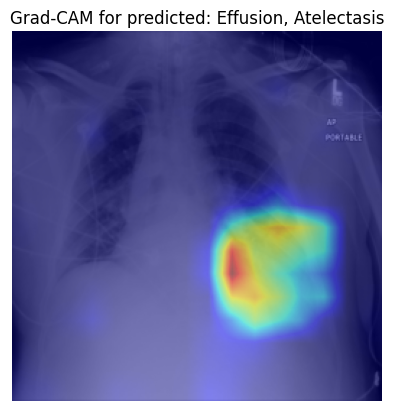

────────────────────────────────────────────── 🚀Params for Inferno ───────────────────────────────────────────────

{
    'input_csv': 'data/inferno/calibration_test.csv',
    'model_path': 'data/inferno/combinedML50/learnt.rds',
    'quantiles': [0.055, 0.25, 0.75, 0.945],
    'input_values': {
        'LOGIT_ATELECTASIS': [None, None, None, -0.288856, -0.28885602951049805],
        'LOGIT_EFFUSION': [1.09, 0.75, 0.75, 0.2818384, 0.28183844685554504],
        'GENDER': ['M', 'F', None, 'M', None],
        'AGE': [57, None, None, 57, None],
        'VP': ['AP', 'PA'],
        'LABEL_EFFUSION': [0, 1],
        'LABEL_ATELECTASIS': [0, 1]
    },
    'predictors': ['LOGIT_ATELECTASIS', 'LOGIT_EFFUSION', 'GENDER', 'AGE'],
    'predictands': ['VP', 'LABEL_EFFUSION', 'LABEL_ATELECTASIS']
}

[1] "🔍 Predictor Features:"
  LOGIT_ATELECTASIS LOGIT_EFFUSION GENDER AGE
1                NA      1.0900000      M  57
2                NA      0.7500000      F  NA
3                NA      0.7500000   <NA>  NA
4         -0.288856      0.2818384      M  57
5         -0.288856      0.2818384   <NA>  NA
[1] "🔍 Predictand Targets:"
  VP LABEL_EFFUSION LABEL_ATELECTASIS
1 AP              0                 0
2 PA              0                 0
3 AP              1                 0
4 PA              1                 0
5 AP              0                 1
6 PA              0                 1
7 AP              1                 1
8 PA              1                 1

Registered doParallelSNOW with 10 workers

Closing connections to cores.


───────────────────────────────────────────────── Inferno Results ─────────────────────────────────────────────────

📊 Prediction Values:

0       1       2       3       4
0  0.0846  0.1072  0.1110  0.1355  0.1489
1  0.0875  0.0921  0.0936  0.0855  0.0954
2  0.2313  0.2446  0.2477  0.2268  0.2213
3  0.2753  0.2407  0.2377  0.1759  0.1643
4  0.0508  0.0644  0.0656  0.1039  0.1119
5  0.0464  0.0500  0.0500  0.0616  0.0669
6  0.1054  0.1031  0.1012  0.1217  0.1127
7  0.1187  0.0978  0.0933  0.0891  0.0786

In [1]:
import os
from pathlib import Path
from CNN import run_inferno_prediction, predict_from_image_path

# Move the working directory to the parent folder
WORKDIR = Path("/home/maxvill/InfernoCalibNet")
os.chdir(WORKDIR)

# Retrieving logits from CNN for a given image
(logit_efu, logit_ate), *_ = predict_from_image_path(
    image_path="/home/maxvill/InfernoCalibNet/data/raw/xrays/xrays6/00012236_010.png"
)

# Define predictors & predictands
predictor_sets = [
    {"LOGIT_EFFUSION": 1.09, "AGE": 57, "GENDER": "M"},
    {"LOGIT_EFFUSION": 0.75, "GENDER": "F"},
    {"LOGIT_EFFUSION": 0.75},
    {"LOGIT_EFFUSION": 0.2818384, "LOGIT_ATELECTASIS": -0.288856, "AGE": 57, "GENDER": "M"},
    {"LOGIT_EFFUSION": logit_efu, "LOGIT_ATELECTASIS": logit_ate},
]

predictand_input = {
    "VP": ["AP", "PA"],
    "LABEL_EFFUSION": [0, 1],
    "LABEL_ATELECTASIS": [0, 1],
}

# Running Infeno prediction
# The original paths are set relative to root of project override for custom paths
df, result = run_inferno_prediction(
    predictor_sets=predictor_sets, predictand_input=predictand_input
)

### 🧠 What We’re Seeing: Inferno Prediction Workflow

This output illustrates how the Inferno framework is used to generate calibrated probabilistic predictions for clinical variables by combining CNN-derived logits with auxiliary patient data.

### 🔁 Workflow Overview

1. **Image Processing & Logit Extraction**  
   A chest X-ray image is passed through a CNN, which outputs raw logits for relevant conditions (e.g., effusion and atelectasis). These logits serve as structured summaries of the image, not final decisions.

2. **Grad-CAM Heatmap Generation**  
   Alongside logits, a Grad-CAM heatmap is produced to visually highlight the regions of the image most influential to the CNN’s predictions, offering spatial interpretability for clinical review.

3. **Construction of Predictor Sets**  
   A list of hypothetical or partial patient profiles is created. These include a combination of:
   - Logits from the CNN
   - Auxiliary information (e.g., age, gender)

4. **Defining Predictand Combinations**  
   The system defines all combinations of the target variables—view position (`VP`), effusion label, and atelectasis label—for which it will compute posterior probabilities.

5. **Inferno Prediction**  
   For each input profile, Inferno uses Bayesian nonparametric regression to compute the probability distribution over the defined predictand combinations. This yields a personalized, uncertainty-aware output for each case.

### 📊 Interpreting the Output

- **Predictor Features Table**  
  Shows the input data for each profile/configuration, including logits and auxiliary values. Some entries are intentionally partial to allow marginal inference.

- **Predictand Targets Table**  
  Lists all combinations of target labels that will be evaluated/inferred.

- **Prediction Values Table**  
  Shows posterior probabilities for each target combination, given each input profile. Each column corresponds to one predictor set; each row is a possible outcome combination.

This setup allows inference across different levels of input completeness and supports clinical decision-making by providing both probabilistic outcomes and visual model interpretability via heatmaps.


### 🔬 Example: Interpreting a Single Prediction

Each line under "📈 Posterior Probabilities" represents one of the 8 possible combinations of:

**Predictands (Outputs):**
- `View Position (VP)`: AP or PA  
- `LABEL_EFFUSION`: 0 or 1  
- `LABEL_ATELECTASIS`: 0 or 1  

These represent the **possible outcomes** the model is evaluating — there are `2 × 2 × 2 = 8` combinations in total.

The number next to each combination is the **model’s predicted probability** for that exact outcome, taken from **column 4** (i.e. the last column) of the Inferno output matrix.

The rows correspond to the combinations in this fixed order (row index 0 to 7):  
So when you read: `AP, Effusion=1, Atelectasis=0 → 0.2213`  
You’re reading row **2**, column **4** of the prediction matrix — meaning the model predicts a **22.13%** chance of that specific outcome.

This prediction is based on more than just the label combination — it also incorporates the **predictors (inputs)** that generated it:

```json
{
  "LOGIT_EFFUSION": 0.2818384,
  "LOGIT_ATELECTASIS": -0.288856,
  "AGE": 57,
  "GENDER": "M"
}
```

So the line `AP, Effusion=1, Atelectasis=0 → 0.2213` is not just a static lookup — it's the posterior probability for that specific combination **conditioned on the above input**.
